In [21]:
## reload submodule
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [22]:
import pandas as pd

In [23]:
data = pd.read_csv("./data/_^spx_with_leverage.csv", index_col=0, parse_dates=[0], sep=",")
data

,open,high,low,close,volume,signal,leverage
date,,,,,,,
2023-01-03,3853.290039,3878.459961,3794.330078,3824.139893,3959140000,1,1.0
2023-01-04,3840.360107,3873.159912,3815.770020,3852.969971,4414080000,1,1.0
2023-01-05,3839.739990,3839.739990,3802.419922,3808.100098,3893450000,1,1.0
2023-01-06,3823.370117,3906.189941,3809.560059,3895.080078,3923560000,1,1.0
2023-01-09,3910.820068,3950.570068,3890.419922,3892.090088,4311770000,1,1.0
...,...,...,...,...,...,...,...
2025-04-01,5597.529785,5650.569824,5558.520020,5633.069824,4434500000,-1,2.0
2025-04-02,5580.759766,5695.310059,5571.479980,5670.970215,4243830000,-1,2.0
2025-04-03,5492.740234,5499.529785,5390.830078,5396.520020,7210470000,-1,2.0


In [ ]:
from qfin.backtester.runners import bt_signal_change

backtest_params = {"initial_balance": 10000, "default_entry_value": 1, "default_entry_value_max": 10000, "commission": 0.001}

# running a predefined strategy
bt = bt_signal_change(data, leverage_column="leverage", **backtest_params)

In [25]:
stats = bt.stats()
stats

Start                     2023-01-03 00:00:00
End                       2025-04-07 00:00:00
Duration                    825 days 00:00:00
Exposure Time [%]                   96.296296
Equity Start                            10000
Equity Peak                             51098
Equity Final                            51098
Equity Return [%]                      410.98
Balance Start                           10000
Balance Peak                            51098
Balance Final                           51098
Balance Return [%]                     410.98
Gross Return [%]                       159.71
Total Commissions                         697
Return (Ann.) [%]                  106.464876
Volatility (Ann.) [%]               39.640391
CAGR [%]                            64.583082
Sharpe Ratio                         -9.92763
Sortino Ratio                       -41.20667
Calmar Ratio                        13.743648
Max. Drawdown [%]                   -7.746479
Avg. Drawdown [%]                 

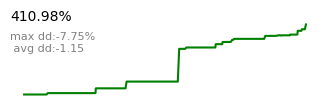

In [26]:
bt.thumbnail()

In [27]:
bt.trades()

,is_long,leverage,entry_value,entry_price,entry_bar,entry_commission,entry_time,exit_value,exit_price,exit_commission,exit_bar,exit_time,pnl,return_pct
0,False,1.0,9990.0,4179.759766,21,10.0,2023-02-02,10813.110431,3861.590088,10.813110,46,2023-03-10,823.110431,0.082393
1,True,1.5,14985.0,3861.590088,46,15.0,2023-03-10,17807.577565,4588.959961,17.807578,143,2023-07-31,2822.577565,0.188360
2,False,3.5,34965.0,4588.959961,143,35.0,2023-07-31,38969.774508,4117.370117,38.969775,206,2023-10-27,4004.774508,0.114537
3,True,7.0,69930.0,4117.370117,206,70.0,2023-10-27,89240.629788,5254.350098,89.240630,310,2024-03-28,19310.629788,0.276142
4,False,1.4,13986.0,5254.350098,310,14.0,2024-03-28,14794.430851,4967.229980,14.794431,325,2024-04-19,808.430851,0.057803
5,True,1.4,13986.0,4967.229980,325,14.0,2024-04-19,15956.873800,5667.200195,15.956874,384,2024-07-16,1970.873800,0.140918
6,False,1.4,13986.0,5667.200195,384,14.0,2024-07-16,15282.764640,5186.330078,15.282765,398,2024-08-05,1296.764640,0.092719
7,True,1.4,13986.0,5186.330078,398,14.0,2024-08-05,15232.065805,5648.399902,15.232066,417,2024-08-30,1246.065805,0.089094
8,False,1.4,13986.0,5648.399902,417,14.0,2024-08-30,14606.580512,5408.419922,14.606581,421,2024-09-06,620.580512,0.044372
9,True,1.4,13986.0,5408.419922,421,14.0,2024-09-06,15749.242426,6090.270020,15.749242,485,2024-12-06,1763.242426,0.126072


In [ ]:
bt.plot()